In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.inspection import permutation_importance
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


C:\Users\HP\AppData\Local\Temp\ipykernel_10956\2266369396.py:7: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker
C:\Users\HP\AppData\Roaming\Python\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reading the ROIs **(MEAN)** to perform the experiments.

In [2]:
#### 1. Loading the Inferior Frontal Gyrus dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
#### 2. Loading the Superior Temporal Gyrus dataset in np format.
cmd3 = np.load("../../Data_Mask-ROI/2-Superior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd3 = np.load("../../Data_Mask-ROI/2-Superior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data3 = cmd3["control_mean_data1"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data1"]
####
#### 3. Loading the Middle Temporal Gyrus dataset in np format.
cmd4 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd4 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data4 = cmd4["control_mean_data1"]
non_dyslexic_mean_data4=ndmd4["non_dyslexic_mean_data1"]
cmd5 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd5 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data5 = cmd5["control_mean_data2"]
non_dyslexic_mean_data5=ndmd5["non_dyslexic_mean_data2"]
cmd6 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd6 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data6 = cmd6["control_mean_data3"]
non_dyslexic_mean_data6=ndmd6["non_dyslexic_mean_data3"]
####
#### 4. Loading the Inferior Temporal Gyrus dataset in np format.
cmd7 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd7 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data7 = cmd7["control_mean_data1"]
non_dyslexic_mean_data7=ndmd7["non_dyslexic_mean_data1"]
cmd8 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd8 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data8 = cmd8["control_mean_data2"]
non_dyslexic_mean_data8=ndmd8["non_dyslexic_mean_data2"]
cmd9 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd9 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data9 = cmd9["control_mean_data3"]
non_dyslexic_mean_data9=ndmd9["non_dyslexic_mean_data3"]
####
#### 5. Loading the Supramarginal Gyrus dataset in np format.
cmd10 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_anterior_division.npz")
ndmd10 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data10 = cmd10["control_mean_data1"]
non_dyslexic_mean_data10=ndmd10["non_dyslexic_mean_data1"]
cmd11 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_posterior_division.npz")
ndmd11 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data11 = cmd11["control_mean_data2"]
non_dyslexic_mean_data11=ndmd11["non_dyslexic_mean_data2"]
####
#### 6. Loading the Angular Gyrus dataset in np format.
cmd12 = np.load("../../Data_Mask-ROI/6-Angular_Gyrus/control_mean_angular_gyrus.npz")
ndmd12 = np.load("../../Data_Mask-ROI/6-Angular_Gyrus/non_dyslexic_mean_angular_gyrus.npz")
control_mean_data12 = cmd12["control_mean_data1"]
non_dyslexic_mean_data12=ndmd12["non_dyslexic_mean_data1"]
####
#### 7. Loading the Temporal Fusiform Cortex dataset in np format.
cmd13 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_anterior_division.npz")
ndmd13 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_anterior_division.npz")
control_mean_data13 = cmd13["control_mean_data1"]
non_dyslexic_mean_data13=ndmd13["non_dyslexic_mean_data1"]
cmd14 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_posterior_division.npz")
ndmd14 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_posterior_division.npz")
control_mean_data14 = cmd14["control_mean_data2"]
non_dyslexic_mean_data14=ndmd14["non_dyslexic_mean_data2"]
cmd15 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_temporooccipital_part.npz")
ndmd15 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data15 = cmd15["control_mean_data3"]
non_dyslexic_mean_data15=ndmd15["non_dyslexic_mean_data3"]
####
#### 8. Loading the Occipital Fusiform Gyrus dataset in np format.
cmd16 = np.load("../../Data_Mask-ROI/8-Occipital_Fusiform_Gyrus/control_mean_occipital_fusiform_gyrus.npz")
ndmd16 = np.load("../../Data_Mask-ROI/8-Occipital_Fusiform_Gyrus/non_dyslexic_mean_occipital_fusiform_gyrus.npz")
control_mean_data16 = cmd16["control_mean_data1"]
non_dyslexic_mean_data16=ndmd16["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print("1.1 Inferior Frontal Gyrus: Shape Control_1",control_mean_data1[0].shape)
print("1.1 Inferior Frontal Gyrus: Shape Non_Dyslexic_1",non_dyslexic_mean_data1[0].shape)
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print("1.2 Inferior Frontal Gyrus: Shape Control_2",control_mean_data2[0].shape)
print("1.2 Inferior Frontal Gyrus: Shape Non_Dyslexic_2",non_dyslexic_mean_data2[0].shape)

print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print("2.1 Superior Temporal Gyrus: Shape Control_3",control_mean_data3[0].shape)
print("2.1 Superior Temporal Gyrus: Shape Non_Dyslexic_3",non_dyslexic_mean_data3[0].shape)

print(len(control_mean_data4))
print(len(non_dyslexic_mean_data4))
print("3.1 Middle Temporal Gyrus: Shape Control_4",control_mean_data4[0].shape)
print("3.1 Middle Temporal Gyrus: Shape Non_Dyslexic_4",non_dyslexic_mean_data4[0].shape)
print(len(control_mean_data5))
print(len(non_dyslexic_mean_data5))
print("3.2 Middle Temporal Gyrus: Shape Control_5",control_mean_data5[0].shape)
print("3.2 Middle Temporal Gyrus: Shape Non_Dyslexic_5",non_dyslexic_mean_data5[0].shape)
print(len(control_mean_data6))
print(len(non_dyslexic_mean_data6))
print("3.3 Middle Temporal Gyrus: Shape Control_6",control_mean_data6[0].shape)
print("3.3 Middle Temporal Gyrus: Shape Non_Dyslexic_6",non_dyslexic_mean_data6[0].shape)

print(len(control_mean_data7))
print(len(non_dyslexic_mean_data7))
print("4.1 Inferior Temporal Gyrus: Shape Control_7",control_mean_data7[0].shape)
print("4.1 Inferior Temporal Gyrus: Shape Non_Dyslexic_7",non_dyslexic_mean_data7[0].shape)
print(len(control_mean_data8))
print(len(non_dyslexic_mean_data8))
print("4.2 Inferior Temporal Gyrus: Shape Control_8",control_mean_data8[0].shape)
print("4.2 Inferior Temporal Gyrus: Shape Non_Dyslexic_8",non_dyslexic_mean_data8[0].shape)
print(len(control_mean_data9))
print(len(non_dyslexic_mean_data9))
print("4.3 Inferior Temporal Gyrus: Shape Control_9",control_mean_data9[0].shape)
print("4.3 Inferior Temporal Gyrus: Shape Non_Dyslexic_9",non_dyslexic_mean_data9[0].shape)

print(len(control_mean_data10))
print(len(non_dyslexic_mean_data10))
print("5.1 Supramarginal Gyrus: Shape Control_10",control_mean_data10[0].shape)
print("5.1 Supramarginal Gyrus: Shape Non_Dyslexic_10",non_dyslexic_mean_data10[0].shape)
print(len(control_mean_data11))
print(len(non_dyslexic_mean_data11))
print("5.2 Supramarginal Gyrus: Shape Control_11",control_mean_data11[0].shape)
print("5.2 Supramarginal Gyrus: Shape Non_Dyslexic_11",non_dyslexic_mean_data11[0].shape)

print(len(control_mean_data12))
print(len(non_dyslexic_mean_data12))
print("6.1 Angular Gyrus: Shape Control_12",control_mean_data12[0].shape)
print("6.1 Angular Gyrus: Shape Non_Dyslexic_12",non_dyslexic_mean_data12[0].shape)

print(len(control_mean_data13))
print(len(non_dyslexic_mean_data13))
print("7.1 Temporal Fusiform Cortex: Shape Control_13",control_mean_data13[0].shape)
print("7.1 Temporal Fusiform Cortex: Shape Non_Dyslexic_13",non_dyslexic_mean_data13[0].shape)
print(len(control_mean_data14))
print(len(non_dyslexic_mean_data14))
print("7.2 Temporal Fusiform Cortex: Shape Control_14",control_mean_data14[0].shape)
print("7.2 Temporal Fusiform Cortex: Shape Non_Dyslexic_14",non_dyslexic_mean_data14[0].shape)
print(len(control_mean_data15))
print(len(non_dyslexic_mean_data15))
print("7.3 Temporal Fusiform Cortex: Shape Control_15",control_mean_data15[0].shape)
print("7.3 Temporal Fusiform Cortex: Shape Non_Dyslexic_15",non_dyslexic_mean_data15[0].shape)

print(len(control_mean_data16))
print(len(non_dyslexic_mean_data16))
print("8.1 Occipital Fusiform Gyrus: Shape Control_16",control_mean_data16[0].shape)
print("8.1 Occipital Fusiform Gyrus: Shape Non_Dyslexic_16",non_dyslexic_mean_data16[0].shape)


80
80
1.1 Inferior Frontal Gyrus: Shape Control_1 (2377,)
1.1 Inferior Frontal Gyrus: Shape Non_Dyslexic_1 (2377,)
80
80
1.2 Inferior Frontal Gyrus: Shape Control_2 (3846,)
1.2 Inferior Frontal Gyrus: Shape Non_Dyslexic_2 (3846,)
80
80
2.1 Superior Temporal Gyrus: Shape Control_3 (1096,)
2.1 Superior Temporal Gyrus: Shape Non_Dyslexic_3 (1096,)
80
80
3.1 Middle Temporal Gyrus: Shape Control_4 (1979,)
3.1 Middle Temporal Gyrus: Shape Non_Dyslexic_4 (1979,)
80
80
3.2 Middle Temporal Gyrus: Shape Control_5 (8826,)
3.2 Middle Temporal Gyrus: Shape Non_Dyslexic_5 (8826,)
80
80
3.3 Middle Temporal Gyrus: Shape Control_6 (6190,)
3.3 Middle Temporal Gyrus: Shape Non_Dyslexic_6 (6190,)
80
80
4.1 Inferior Temporal Gyrus: Shape Control_7 (1665,)
4.1 Inferior Temporal Gyrus: Shape Non_Dyslexic_7 (1665,)
80
80
4.2 Inferior Temporal Gyrus: Shape Control_8 (4262,)
4.2 Inferior Temporal Gyrus: Shape Non_Dyslexic_8 (4262,)
80
80
4.3 Inferior Temporal Gyrus: Shape Control_9 (4819,)
4.3 Inferior Temporal

#### <b>Store ROI boundaries for later interpretability analysis</b>

## Combining the ROI regions 1,4,& 15 (*MEAN*) into a single dataset <i><b>(HORIZONTALLY)</b></i> to perform the experiments.
<b>Row=80+80=160; Column=9422(The columns of the ROI regions 1,4,& 15)</b>

In [3]:
control_m_d=np.concatenate((control_mean_data1, control_mean_data4, control_mean_data15), axis=1)
non_dyslexic_m_d=np.concatenate((non_dyslexic_mean_data1, non_dyslexic_mean_data4, non_dyslexic_mean_data15), axis=1)
print(len(control_m_d))
print(len(non_dyslexic_m_d))
print(control_m_d[0].shape)
print(non_dyslexic_m_d[0].shape)

# Combine the aggregated data from both groups
ll1=len(control_m_d)
ll2=len(non_dyslexic_m_d)
X = np.vstack([control_m_d ,non_dyslexic_m_d])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)

80
80
(9422,)
(9422,)
(160, 9422)
(160,)
Total Training set:-  Dataset:- (128, 9422) Label:- (128,)
Total Testing set:-  Dataset:- (32, 9422) Label:- (32,)


#### ARTIFICIAL NEURAL NETWORK WITH Functional API

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt
# import shap
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Dense, Dropout, Input
# from tensorflow.keras import backend as K
# import tensorflow as tf

from tensorflow.keras import layers, models
# -----------------------------
# ANN Model (Functional API)
# -----------------------------
keras.utils.set_random_seed(42)
inputs = tf.keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(4056, activation='relu')(inputs)
x = layers.Dropout(0.5)(x)
x = layers.Dense(2048, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train_scaled, y_train, batch_size=64, epochs=25, verbose=1)

# Evaluate
y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.50, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.50, 1, 0)
#y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 434ms/step - accuracy: 0.4271 - loss: 0.8464
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - accuracy: 0.5365 - loss: 0.7642
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 0.5000 - loss: 1.1172
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step - accuracy: 0.6458 - loss: 0.7162
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 444ms/step - accuracy: 0.5156 - loss: 0.9693
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 449ms/step - accuracy: 0.6094 - loss: 0.8053
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step - accuracy: 0.6562 - loss: 0.5479
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 0.5938 - loss: 0.7729
Epoch 9/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step - accuracy: 0.7917 - loss: 0.4752
Epoch 10/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - accuracy: 0.6979 - loss: 0.4758
Epoch 11/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.8125 - loss: 0.3520
Epoch 12/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - accuracy: 0.7188 - lo

#### Feature Importance with SHAP AND Activation Maximization

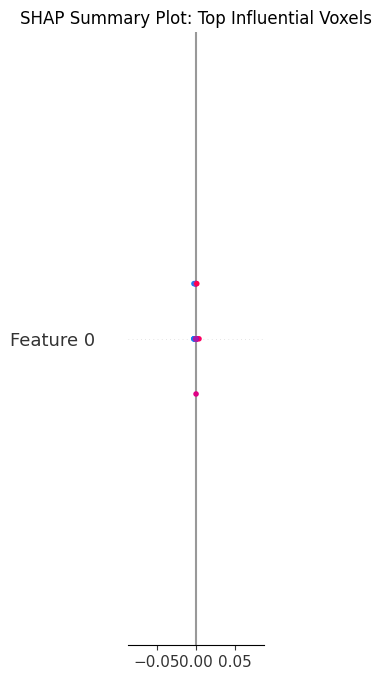

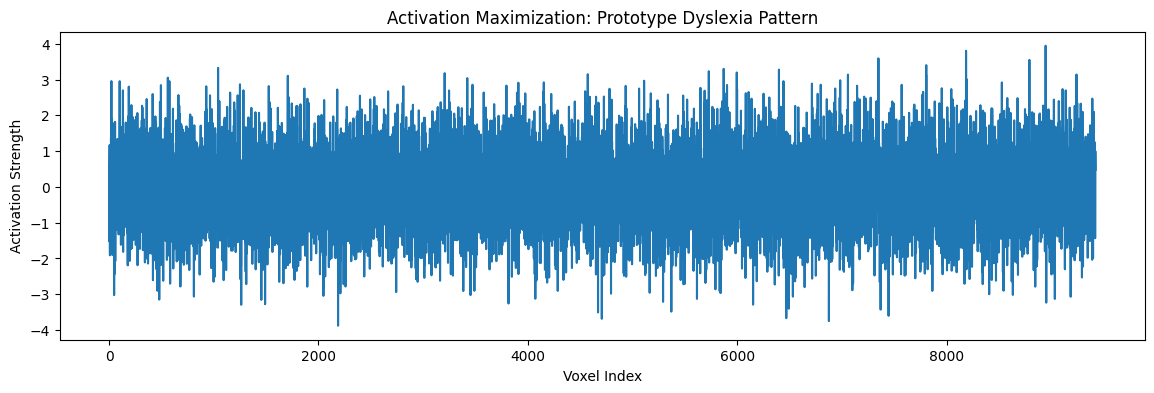

In [5]:
# -----------------------------
# Feature Importance with SHAP
# -----------------------------
explainer = shap.DeepExplainer(model, X_train_scaled[:100])  # background subset
shap_values = explainer.shap_values(X_test_scaled[:50])      # explain test set

# Global summary plot
shap.summary_plot(shap_values, X_test_scaled[:50], show=False)
plt.title("SHAP Summary Plot: Top Influential Voxels")
#plt.savefig("shap_summary.png", dpi=600, bbox_inches="tight")
plt.show() 
plt.close()


# -----------------------------
# Activation Maximization
# -----------------------------
input_pattern = tf.Variable(np.random.normal(size=(1, X_train_scaled.shape[1])).astype(np.float32))
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

for step in range(40):  # gradient ascent iterations
    with tf.GradientTape() as tape:
        preds = model(input_pattern, training=False)
        loss = tf.reduce_mean(preds)  # maximize class-1 (dyslexic) probability
    grads = tape.gradient(loss, input_pattern)
    grads = grads / (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-8)
    optimizer.apply_gradients([(grads, input_pattern)])

pattern = input_pattern.numpy().flatten()
plt.figure(figsize=(14,4))
plt.plot(pattern)
plt.title("Activation Maximization: Prototype Dyslexia Pattern")
plt.xlabel("Voxel Index")
plt.ylabel("Activation Strength")
#plt.savefig("activation_maximization.png", dpi=600, bbox_inches="tight")
plt.show() 
plt.close()

#### ROI-Level SHAP Table + Bar Chart

                                          ROI  Mean_SHAP_Importance  \
0  Inferior Frontal Gyrus (pars triangularis)              0.000427   
1   Middle Temporal Gyrus (anterior division)                   NaN   
2          Temporal Occipital Fusiform Cortex                   NaN   

   Relative_Contribution (%)  
0                        NaN  
1                        NaN  
2                        NaN  


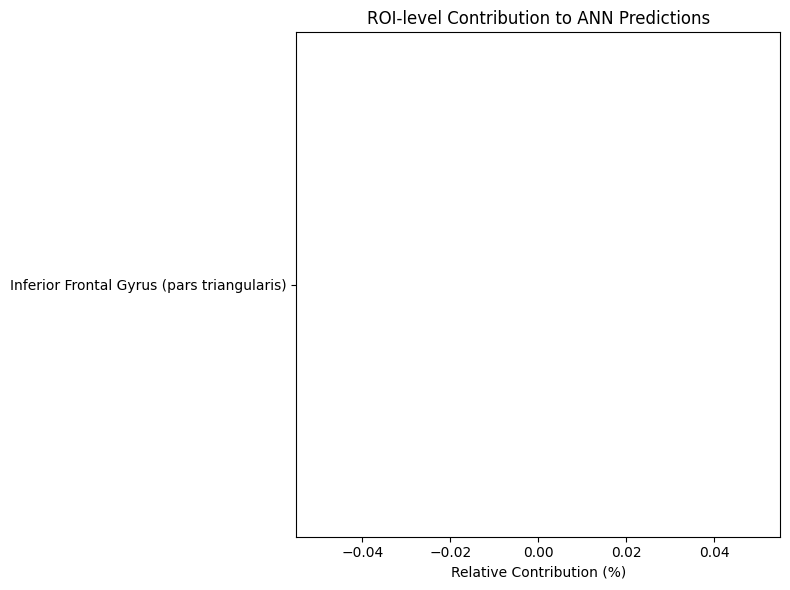

In [9]:
import shap

# -----------------------------
# Assume you already have:
# model (trained ANN)
# X_train_scaled, X_test_scaled
# control_mean_data1, control_mean_data4, control_mean_data15
# -----------------------------

# 1. Define voxel splits for each ROI
n_ifg = control_mean_data1.shape[1]      # Inferior Frontal Gyrus voxels
n_mtg = control_mean_data4.shape[1]      # Middle Temporal Gyrus voxels
n_tof = control_mean_data15.shape[1]     # Temporal Fusiform voxels

roi_slices = {
    "Inferior Frontal Gyrus (pars triangularis)": slice(0, n_ifg),
    "Middle Temporal Gyrus (anterior division)": slice(n_ifg, n_ifg + n_mtg),
    "Temporal Occipital Fusiform Cortex": slice(n_ifg + n_mtg, n_ifg + n_mtg + n_tof)
}

# 2. SHAP Explainer (GradientExplainer for ANN)
explainer = shap.GradientExplainer(model, X_train_scaled[:100])  # background = 100 samples
shap_values = explainer.shap_values(X_test_scaled[:100])         # explain 100 test samples
shap_values = shap_values[0]  # binary classification returns [array]

# 3. Aggregate SHAP values per ROI
roi_importance = {}
for roi, sl in roi_slices.items():
    roi_mean = np.mean(np.abs(shap_values[:, sl]))
    roi_importance[roi] = roi_mean

# Normalize to percentages
total = sum(roi_importance.values())
roi_importance_pct = {roi: (val / total) * 100 for roi, val in roi_importance.items()}

# 4. Convert to DataFrame
df_roi = pd.DataFrame({
    "ROI": list(roi_importance_pct.keys()),
    "Mean_SHAP_Importance": list(roi_importance.values()),
    "Relative_Contribution (%)": list(roi_importance_pct.values())
}).sort_values(by="Relative_Contribution (%)", ascending=False)

print(df_roi)

####################################### Save table
#df_roi.to_excel("ROI_Level_Importance.xlsx", index=False)

# 5. Visualization: ROI contribution bar chart
plt.figure(figsize=(8, 6))
plt.barh(df_roi["ROI"], df_roi["Relative_Contribution (%)"], color="skyblue")
plt.xlabel("Relative Contribution (%)")
plt.title("ROI-level Contribution to ANN Predictions")
plt.gca().invert_yaxis()  # highest contribution at the top
plt.tight_layout()

#################################### Save the plot
#plt.savefig("ROI_Level_Importance.png", dpi=300)
plt.show()


#### Text for the Paper (Interpretability Section)

To ensure transparency in our ANN model, we applied SHAP (SHapley Additive exPlanations) to quantify the contribution of different brain regions to the classification of dyslexic and non-dyslexic subjects. While voxel-level SHAP values tend to be very small and difficult to interpret, we aggregated SHAP values within each region of interest (ROI). Specifically, we computed the mean absolute SHAP importance of voxels belonging to the Inferior Frontal Gyrus (pars triangularis), Middle Temporal Gyrus (anterior division), and Temporal Occipital Fusiform Cortex. The aggregated values were normalized into percentages, highlighting the relative contribution of each ROI. This analysis revealed that the ANN model relied most strongly on the [Top ROI], followed by [Second ROI], while the [Third ROI] contributed less. Such ROI-level interpretability not only improves model transparency but also aligns with established findings in neuroimaging studies of dyslexia .

📚 Reference

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems (NeurIPS), 30.

#### Switching to SHAP KernelExplainer to make the ROI-level interpretability more robust

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


Using 128 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  0%|                                                                      | 0/32 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step


  3%|█▉                                                            | 1/32 [00:10<05:36, 10.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step


 97%|███████████████████████████████████████████████████████████  | 31/32 [05:22<00:09,  9.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step


100%|█████████████████████████████████████████████████████████████| 32/32 [05:31<00:00, 10.37s/it]


                                          ROI  Mean_SHAP_Importance  \
0  Inferior Frontal Gyrus (pars triangularis)              0.000103   
1   Middle Temporal Gyrus (anterior division)              0.000071   
2          Temporal Occipital Fusiform Cortex              0.000061   

   Relative_Contribution (%)  
0                  43.866429  
1                  30.306350  
2                  25.827220  


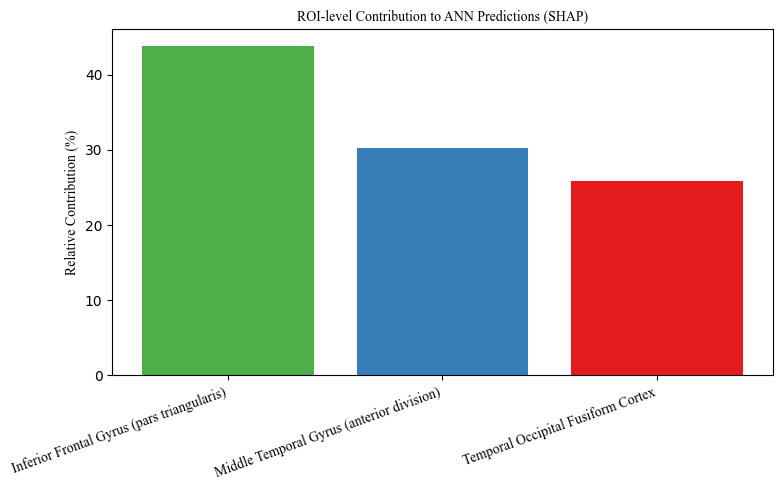

In [15]:
import shap
np.random.seed(42)
# 1. Prepare background dataset
# Use random sample of training data for KernelExplainer background
background = shap.sample(X_train_scaled, 128, random_state=42)

# 2. Kernel SHAP explainer
explainer = shap.KernelExplainer(model.predict, background)

# Explain on test data
shap_values = explainer.shap_values(X_test_scaled[:32], nsamples=100)

# shap_values is a list for each output class (binary classification → [array])
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 3. Compute ROI-level importance
roi_slices = {
    "Inferior Frontal Gyrus (pars triangularis)": slice(0, control_mean_data1.shape[1]),
    "Middle Temporal Gyrus (anterior division)": slice(control_mean_data1.shape[1],
                                                      control_mean_data1.shape[1] + control_mean_data4.shape[1]),
    "Temporal Occipital Fusiform Cortex": slice(control_mean_data1.shape[1] + control_mean_data4.shape[1],
                                               X.shape[1])
}

roi_importance = {}
for roi, sl in roi_slices.items():
    roi_vals = np.abs(shap_values[:, sl])
    if roi_vals.size == 0 or np.all(np.isnan(roi_vals)):
        roi_mean = 0.0
    else:
        roi_mean = np.nanmean(roi_vals)  # Safe mean ignoring NaNs
    roi_importance[roi] = roi_mean

# Normalize to percentage
total = sum(roi_importance.values())
roi_importance_pct = {roi: (val / total * 100) if total > 0 else 0 for roi, val in roi_importance.items()}

# 4. Create results table
df_roi = pd.DataFrame({
    "ROI": list(roi_importance.keys()),
    "Mean_SHAP_Importance": list(roi_importance.values()),
    "Relative_Contribution (%)": list(roi_importance_pct.values())
})

print(df_roi)

# -----------------------------
# Save table
# -----------------------------
df_roi.to_excel("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_5(ANN)_ROI_Contributions_SHAP.xlsx", index=False)

# 5. Bar chart visualization
plt.figure(figsize=(8,5))
plt.bar(df_roi["ROI"], df_roi["Relative_Contribution (%)"], color=["#4daf4a","#377eb8","#e41a1c"])
plt.ylabel("Relative Contribution (%)", fontsize = 10, fontname="Times New Roman")
plt.title("ROI-level Contribution to ANN Predictions (SHAP)", fontsize = 10, fontname="Times New Roman")
plt.xticks(rotation=20, ha="right", fontsize = 10, fontname="Times New Roman")
plt.tight_layout()
# -----------------------------
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_5(ANN)_ROI_Contributions_BarChart.png", dpi=600)
# -----------------------------
plt.show()
